# Analyzing electrochemical noise using Python

This notebook shows how to analyze electrochemical noise (EN) data using [PyPalmSens](https://dev.palmsens.com/python/latest/_attachments).

Sample data were measured using an EmStat4S with a dummy cell consisting of a Li-ion battery. The Working Electrode (WE) was connected to the positive terminal of the battery (+), the Reference Electrode (RE) to the negative terminal (-), and ground (GND) in series with a 1 GΩ resistor to the negative terminal (-).

The data were measured using the [ChronoAmperometry](https://dev.palmsens.com/python/latest/_attachments/reference/methods/chrono_amperometry/) method using the snippet below. We set the measurement interval to 1 second to have a sampling rate of 1 Hz, and we allow the measurement to run for 1 hour. We record the WE potential in addition to the current. 

```python
import pypalmsens as ps

method = ps.ChronoAmperometry(
    current_range={'min': '100nA', 'max': '100mA', 'start': '100nA'},
    interval_time=1.0,
    run_time=3600,
    record_we_potential=True,
)

measurement = ps.measure(ca)

ps.save_session_file('EN_1Hz_3600s.pssession', [measurement])
```

The sample data are included alongside this notebook. For the data analysis, we follow the procedure described by Barrozo et al. (2020). The data analysis consists of 3 steps:

1. Detrend the data. 
2. Multiply data by a 'window'. 
3. Calculating the power spectrum or power spectral density (PSD).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pypalmsens as ps

## Loading data

Load the measurement using [`load_session_file()`](https://dev.palmsens.com/python/latest/_attachments/reference/io/#pypalmsens.load_session_file). 

This returns a [measurement class](https://dev.palmsens.com/python/latest/_attachments/data/#measurement) that contains the data, measurement details, and device metadata. We extract the time, current, and potential arrays.

In [2]:
area = 1  # electrode area, used to normalize current to current density

measurement = ps.load_session_file('EN_1Hz_3600s.pssession')[0]
print(measurement)

t = np.array(measurement.dataset['Time'])
E = np.array(measurement.dataset['PotentialExtraRE'])
I = np.array(measurement.dataset['Current'])

I = I / area

Measurement(title=Chronoamperometry, timestamp=10-Dec-25 11:14:01, device=EmStat4HR)


## Detrend

Use the [numpy polynomial module](https://numpy.org/doc/stable/reference/routines.polynomials.classes.html) to fit a polynomial trendline through the data. 

To remove the drift, subtract the trendline from the data.

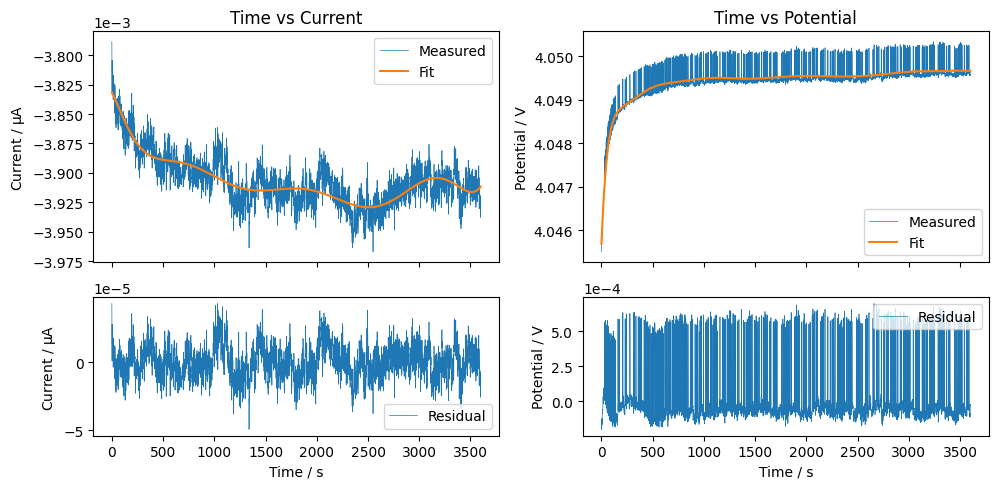

In [3]:
pI = np.polynomial.Polynomial.fit(t, I, 10)
pE = np.polynomial.Polynomial.fit(t, E, 15)

I_res = I - pI(t)
E_res = E - pE(t)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 5), height_ratios=(5,3))

axes[0,0].plot(t, I, label='Measured', linewidth=0.5)
axes[0,0].plot(t, pI(t), label='Fit')
axes[0,0].ticklabel_format(scilimits=(-1, 4), style='sci')
axes[0,0].set_ylabel(r"Current / $\mathrm{\mu A}$")
axes[0,0].set_title('Time vs Current')
axes[0,0].tick_params('x', labelbottom=False)
axes[0,0].legend()

axes[0,1].plot(t, E, label='Measured', linewidth=0.5)
axes[0,1].plot(t, pE(t), label='Fit')
axes[0,1].ticklabel_format(scilimits=(-1, 4), style='sci')
axes[0,1].set_ylabel("Potential / V")
axes[0,1].set_title('Time vs Potential')
axes[0,1].tick_params('x', labelbottom=False)
axes[0,1].legend()

axes[1,0].plot(t, I_res, label='Residual', linewidth=0.5)
axes[1,0].ticklabel_format(scilimits=(-1, 3), style='sci')
axes[1,0].set_xlabel("Time / s")
axes[1,0].set_ylabel(r"Current / $\mathrm{\mu A}$")
axes[1,0].sharex(axes[0,0])
axes[1,0].legend(loc='lower right')

axes[1,1].plot(t, E_res, label='Residual', linewidth=0.5)
axes[1,1].ticklabel_format(scilimits=(-1, 3), style='sci')
axes[1,1].sharex(axes[0,1])
axes[1,1].set_xlabel("Time / s")
axes[1,1].set_ylabel("Potential / V")
axes[1,1].legend(loc='upper right')

fig.tight_layout()

## Apply Hann Window

Generate the Hann window using the [signal.windows.hann](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.windows.hann.html) function. The Hann window can be applied by simply multiplying with the current and potential arrays of the same length.

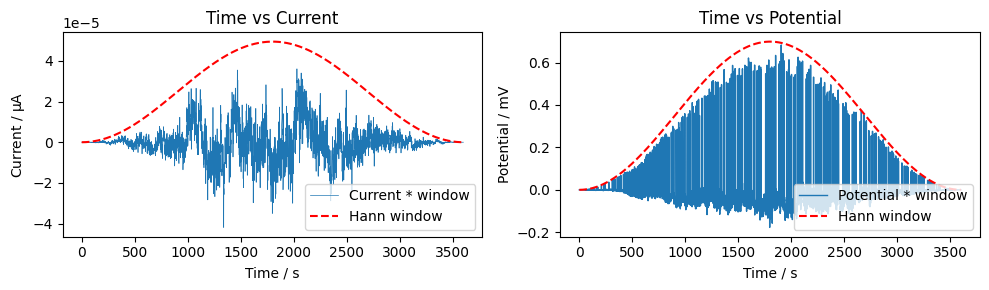

In [4]:
Hw = signal.windows.hann(len(t))

I_h = I_res * Hw
E_h = E_res * Hw

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

# axes[0].plot(t, I_res, label='Current', linewidth=0.2)
axes[0].plot(t, I_h, label='Current * window', linewidth=0.5)
axes[0].plot(t, Hw * np.abs(I_res).max(), label='Hann window', linestyle='--', color='red')
axes[0].set_xlabel("Time / s")
axes[0].set_ylabel(r"Current / $\mathrm{\mu A}$")
axes[0].set_title('Time vs Current')
axes[0].legend(loc='lower right')

# axes[1].plot(t, E_res * 1000, label='Potential', linewidth=1)
axes[1].plot(t, E_h * 1000, label='Potential * window', linewidth=1)
axes[1].plot(t, Hw * np.abs(E_res).max() * 1000, label='Hann window', linestyle='--', color='red')
axes[1].set_xlabel("Time / s")
axes[1].set_ylabel("Potential / mV")
axes[1].set_title('Time vs Potential')
axes[1].legend(loc='lower right')

fig.tight_layout()

## Calculate Power Spectrum

Calculate the PSD using the [signal.periodogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html) function. This performs the Fourier transform of the current or potential and calculates the spectral densities.

We pass in the current and potential arrays with the Hann window applied and the sampling frequency (1 Hz). This returns the frequency and PSD arrays for the current and potential with the units $\mathrm{\mu A^2\ Hz^{-1}}$ and $\mathrm{V^2\ Hz^{-1}}$.


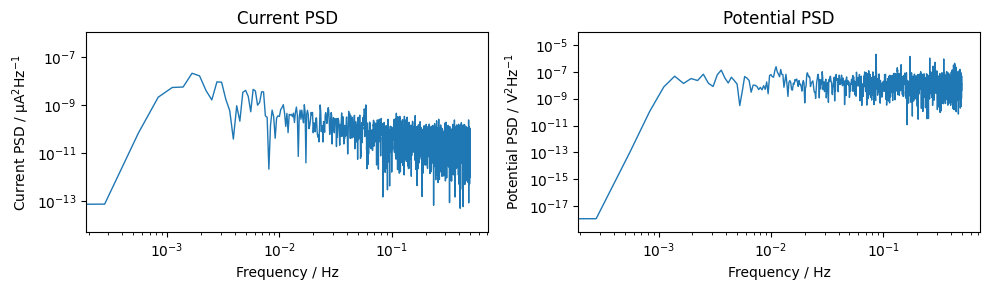

In [5]:
from mpl_toolkits.axes_grid1 import host_subplot

freq_E, E_psd = signal.periodogram(E_h, fs=1.0)
freq_I, I_psd = signal.periodogram(I_h, fs=1.0)

assert np.all(freq_E == freq_I)

freq = freq_E

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

ax1.loglog(freq, I_psd, label='Current', linewidth=1)
ax1.set_ylim(ymin=I_psd[1:].min() / 10)
ax1.set_xlabel('Frequency / Hz')
ax1.set_ylabel(r'Current PSD / $\mathrm{\mu A^2 Hz^{-1}}$')
ax1.set_title('Current PSD')

ax2.loglog(freq, E_psd, label='Potential', linewidth=1)
ax2.set_ylim(ymin=E_psd[1:].min() / 10)
ax2.set_xlabel('Frequency / Hz')
ax2.set_ylabel(r'Potential PSD / $\mathrm{V^2 Hz^{-1}}$')
ax2.set_ylim(ymin=E_psd[1:].min() / 10)
ax2.set_title('Potential PSD')

fig.tight_layout()

## Calculate noise resistance

Following Ohm's law, $R = V/I$, the low-frequency noise impedance $R_{sn}$ is defined as:

$\large{ R_{sn}(f) = \left| \frac{PSD_E(f)}{PSD_I(f)} \right|^{1/2} }$

Use the variables `i` and `j` to delimit the region to fit the linear model. This helps to remove the 0-frequency that results in a 'divide-by-zero' error, and high-frequency vibrations outside the region of interest.


slope: 0.518
y-intercept: 1.778
range: [i=3] 0.0008 Hz to [j=360] 0.1000 Hz (357 points)
Rsn0: 59.9


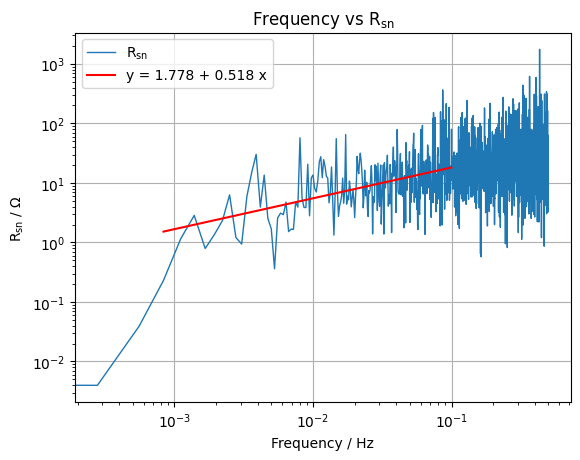

In [6]:
Rsn = np.sqrt(E_psd / I_psd)  

i = 3  # index of initial frequency
j = int(len(t) / 10)  # index of final frequency

x = np.log10(freq[i:j])
y = np.log10(Rsn[i:j])

# convert(): https://github.com/numpy/numpy/issues/26401
ffit = np.polynomial.Polynomial.fit(x, y, 1).convert()
intercept, slope = ffit.coef
Rsn0 = 10**ffit(freq[0])

print(f"slope: {slope:.3f}")
print(f"y-intercept: {intercept:.3f}")
print(f"range: [{i=}] {freq[i]:.4f} Hz to [{j=}] {freq[j]:.4f} Hz ({len(x)} points)")
print(f"Rsn0: {Rsn0:.1f}")

plt.loglog(freq, Rsn, linewidth=1, label=r'$\mathrm{R_{sn}}$')
plt.loglog(10**x, 10**ffit(x), color='red', label=f'y = {intercept:.3f} + {slope:.3f} x');
plt.grid()
plt.xlabel('Frequency / Hz')
plt.ylabel(r'$\mathrm{R_{sn}}$ / $\mathrm{\Omega}$')
plt.title(r'Frequency vs $\mathrm{R_{sn}}$')
plt.legend()